In [1]:
# =============================================
# Cell 1 – Settings & Imports
# =============================================
from pathlib import Path
from IPython.display import display
import os, shutil, hashlib, json, numpy as np, pandas as pd, matplotlib.pyplot as plt

# ------ USER SETTINGS ------
SRC_CSV      = "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/merged_meta_data.csv"
IMAGES_ROOT  = "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/images"
OUT_DIR      = "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/"
COPY_MODE    = "none"      # "none" | "copy" | "symlink"
LIMIT        = None        # e.g. 500 for quick dry-run
MIN_CAT_FREQ = 20          # for label-encoding with __OTHER__

out_dir      = Path(OUT_DIR)
img_out_dir  = out_dir / "images"
out_dir.mkdir(parents=True, exist_ok=True)
if COPY_MODE != "none":
    if not IMAGES_ROOT:
        raise ValueError("IMAGES_ROOT required when COPY_MODE != 'none'")
    
    images_path = Path(IMAGES_ROOT)
    if not images_path.exists():
        raise FileNotFoundError(f"IMAGES_ROOT does not exist: {IMAGES_ROOT}")
    if not images_path.is_dir():
        raise NotADirectoryError(f"IMAGES_ROOT is not a directory: {IMAGES_ROOT}")
    
    img_out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# =============================================
# Cell 2 – Helper Functions
# =============================================
def md5_int(s): return int(hashlib.md5(str(s).encode()).hexdigest(), 16)
def pick_first_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    return None

def safe_basename(p): return os.path.basename(str(p))

def to_label(row):
    d = str(row.get("Diagnosis", "")).strip().lower()
    if d in {"covid-19","covid19","covid 19","covid","sars-cov-2","covid-19"}: return 1
    if d in {"normal"}: return 0
    return np.nan

def to_protected(row):
    if "Gender_encoded" in row and pd.notna(row["Gender_encoded"]): 
        return int(row["Gender_encoded"])
    g = str(row.get("Gender","")).strip().lower()
    if g in ("male","m","1"): return 1
    if g in ("female","f","0"): return 0
    return 0

def to_age(row):
    for k in ("Age","age"):
        if k in row and pd.notna(row[k]):
            try: return float(row[k])
            except: pass
    return np.nan

def encode_category(series):
    s = series.astype("string").fillna("__NA__")
    uniques = sorted(s.unique())
    fwd = {v:i for i,v in enumerate(uniques)}
    inv = dict(enumerate(uniques))
    return s.map(fwd).astype(int), fwd, inv

def encode_with_other(series, min_freq=20, other="__OTHER__"):
    s = series.astype("string").fillna("__NA__").str.strip()
    rare = s.value_counts()[lambda x: x < min_freq].index
    s2 = s.mask(s.isin(rare), other)
    uniques = sorted(s2.unique())
    fwd = {v:i for i,v in enumerate(uniques)}
    inv = dict(enumerate(uniques))
    return s2, s2.map(fwd).astype(int), fwd, inv

def zscore(x: pd.Series):
    m, s = x.mean(skipna=True), x.std(skipna=True)
    if not np.isfinite(s) or s == 0: s = 1.0
    return (x - m) / s, float(m), float(s)

def to_views(df, fname_series):
    if "ViewPosition" in df.columns:
        vp = df["ViewPosition"].astype(str).str.upper().str.strip()
        view_ap = (vp == "AP").astype(float)
        view_pa = (vp == "PA").astype(float)
        mask = ~vp.isin(["AP","PA"])
        if mask.any():
            synth = fname_series[mask].apply(lambda s: md5_int(s) % 2)
            view_ap.loc[mask] = synth
            view_pa.loc[mask] = 1.0 - synth
    else:
        view_ap = fname_series.apply(lambda s: md5_int(s) % 2).astype(float)
        view_pa = 1.0 - view_ap
    return view_ap, view_pa

def place_image(src_root: Path, name: str, dst_dir: Path, mode: str):
    if mode == "none": return True, None
    src = src_root / name
    dst = dst_dir / name
    if not src.exists(): return False, f"missing: {src}"
    dst.parent.mkdir(parents=True, exist_ok=True)
    if mode == "copy":
        shutil.copy2(src, dst)
    elif mode == "symlink":
        try:
            dst.unlink(missing_ok=True)
            dst.symlink_to(src)
        except OSError:
            shutil.copy2(src, dst)
    return True, None

In [3]:
# =============================================
# Cell 3 – Load data & build core features
# =============================================
df = pd.read_csv(SRC_CSV)
if LIMIT: df = df.head(LIMIT).copy()

# Image filename column
img_col = pick_first_col(df, ["File name","filename","image_path","filepath","path","Image","ImageID","Image_Name"])
if not img_col: raise ValueError("Image column not found")
fname = df[img_col].astype(str).map(safe_basename)

# Core targets / protected attribute
label     = df.apply(to_label, axis=1)
protected = df.apply(to_protected, axis=1).astype(int)
age       = df.apply(to_age, axis=1)

view_ap, view_pa = to_views(df, fname)

# ---------- Institution ----------
if "Institution" in df.columns:
    inst_raw = df["Institution"]
elif "Institution_raw" in df.columns:
    inst_raw = df["Institution_raw"]
else:
    inst_raw = pd.Series([pd.NA]*len(df))
inst_clean, inst_codes, inst_fwd, inst_inv = encode_with_other(inst_raw, MIN_CAT_FREQ)
K_inst = len(inst_fwd)

# ---------- Country ----------
country_col = pick_first_col(df, ["Country","country","COUNTRY"])
if country_col:
    ctry_raw = df[country_col]
else:
    ctry_raw = pd.Series([pd.NA]*len(df))
ctry_clean, ctry_codes, ctry_fwd, ctry_inv = encode_with_other(ctry_raw, MIN_CAT_FREQ)
K_ctry = len(ctry_fwd)

# Z-scores (for auditing only)
inst_z,  m_inst,  s_inst  = zscore(inst_codes.astype(float))
ctry_z,  m_ctry,  s_ctry  = zscore(ctry_codes.astype(float))

# Slice thickness z-score (if present)
slice_z = pd.Series(np.nan, index=df.index)
if "Slice" in df.columns:
    x = pd.to_numeric(df["Slice"], errors="coerce")
    mu, sigma = x.mean(skipna=True), x.std(ddof=0, skipna=True)
    if sigma and np.isfinite(sigma) and sigma > 0:
        slice_z = (x - mu) / sigma

# ---------- Final dataframe ----------
out = pd.DataFrame({
    "image_path"     : fname,
    "label"          : label,
    "protected"      : protected,                 # 1 = male, 0 = female
    "age"            : age,
    "sex_male"       : protected.astype(float),
    "sex_female"     : (1-protected).astype(float),
    "view_ap"        : view_ap,
    "view_pa"        : view_pa,
    "Institution_le" : inst_codes,
    "Country_le"     : ctry_codes,
    "Institution_z"  : inst_z,
    "Country_z"      : ctry_z,
    "Slice"          : slice_z,
    "Institution_raw": inst_clean.astype("string"),
    "Country_raw"    : ctry_clean.astype("string"),
    "Gender"         : df["Gender"].astype("string") if "Gender" in df.columns else pd.NA,
})

out = out.dropna(subset=["label"]).reset_index(drop=True)
print(out.shape)
display(out.head(10))

(14486, 16)


,image_path,label,protected,age,sex_male,sex_female,view_ap,view_pa,Institution_le,Country_le,Institution_z,Country_z,Slice,Institution_raw,Country_raw,Gender
0,6_Rahimzadeh_137covid_patient101_SR_4_IM00006.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.997031,Negin radiology located at Sari,Iran,F
1,6_Rahimzadeh_137covid_patient101_SR_4_IM00008.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.959322,Negin radiology located at Sari,Iran,F
2,6_Rahimzadeh_137covid_patient101_SR_4_IM00009.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.940468,Negin radiology located at Sari,Iran,F
3,6_Rahimzadeh_137covid_patient101_SR_4_IM00010.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.921614,Negin radiology located at Sari,Iran,F
4,6_Rahimzadeh_137covid_patient101_SR_4_IM00011.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,0.621467,-0.574334,-0.902760,Negin radiology located at Sari,Iran,F
5,6_Rahimzadeh_137covid_patient101_SR_4_IM00012.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,0.621467,-0.574334,-0.883906,Negin radiology located at Sari,Iran,F
6,6_Rahimzadeh_137covid_patient101_SR_4_IM00013.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,0.621467,-0.574334,-0.865051,Negin radiology located at Sari,Iran,F
7,6_Rahimzadeh_137covid_patient101_SR_4_IM00014.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.846197,Negin radiology located at Sari,Iran,F
8,6_Rahimzadeh_137covid_patient101_SR_4_IM00015.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.827343,Negin radiology located at Sari,Iran,F
9,6_Rahimzadeh_137covid_patient101_SR_4_IM00016.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.808489,Negin radiology located at Sari,Iran,F


In [4]:
# =============================================
# Cell 4 – Protected-group construction (training + reporting)
# =============================================
CANON_COUNTRY = {
    "islamic republic of iran":"Iran","iran":"Iran","iran, islamic republic of":"Iran",
    "russian federation":"Russia","russia":"Russia","ukraine":"Ukraine",
    "turkiye":"Turkey","turkey":"Turkey","italy":"Italy","belgium":"Belgium",
    "-":"UNK","":"UNK","none":"UNK","unknown":"UNK","nan":"UNK"
}
def _norm_country(x): 
    return CANON_COUNTRY.get(str(x).strip().lower(), str(x).title() if str(x).strip() else "UNK")

def make_protected(df, min_group=300, keep_countries=("Iran","Russia"), train_uses=("sex","age")):
    # Sex
    if "Gender" in df.columns:
        sex = df["Gender"].astype(str).str.lower().str[0].map({"f":"f","m":"m"}).fillna("u")
    else:
        sex = np.where(df["sex_male"]>0.5, "m", np.where(df["sex_female"]>0.5, "f", "u"))
        sex = pd.Series(sex, index=df.index)

    # Country
    ctry_raw = df["Country_raw"].fillna("UNK").astype(str)
    ctry_coarse = np.where(ctry_raw.isin(keep_countries), ctry_raw, "Other")

    # Age bands – FIXED HERE
    age_band = pd.cut(df["age"], bins=[-1, 40, 120], labels=["A<40", "A40+"], right=True)
    age_band = age_band.astype("object").fillna("A?")   # <-- important line

    # Reporting key (fine-grained)
    key_report = sex.astype(str) + "·" + ctry_raw.astype(str) + "·" + age_band.astype(str)
    df["protected_report"] = pd.Categorical(key_report).codes

    # Training key (coarser)
    parts = []
    if "sex" in train_uses:    parts.append(sex.astype(str))
    if "country" in train_uses: parts.append(pd.Series(ctry_coarse, index=df.index).astype(str))
    if "age" in train_uses:    parts.append(age_band.astype(str))

    key_train = parts[0] if parts else pd.Series("All", index=df.index)
    for p in parts[1:]:
        key_train = key_train + "·" + p

    # Collapse rare training groups
    rare = key_train.value_counts()[lambda x: x < min_group].index
    key_train = key_train.where(~key_train.isin(rare), "Other")

    # REMOVE UNWANTED GROUPS ENTIRELY
    valid_mask = ~((sex == "u") | (key_train == "Other"))
    df = df[valid_mask].reset_index(drop=True)        # keep only good rows
    key_train = key_train[valid_mask].reset_index(drop=True)
    key_report = key_report[valid_mask].reset_index(drop=True)

    # Now create categorical codes (will be dense: 0,1,2,3 only)
    df["protected"] = pd.Categorical(key_train).codes
    df["protected_report"] = pd.Categorical(key_report).codes  # if you still want it

    # Build clean maps without 'Other' or 'u·A?'
    prot_map_train = dict(enumerate(pd.Categorical(key_train).categories))
    prot_map_report = dict(enumerate(pd.Categorical(key_report).categories))

    return df, prot_map_train, prot_map_report

df, PROT_MAP_TRAIN, PROT_MAP_REPORT = make_protected(
    out.copy(),
    min_group=300,
    keep_countries=("Iran","Russia"),
    train_uses=("sex","age")        # change here if you want country too
)
print("Training groups →", PROT_MAP_TRAIN)
print(f"Number of training groups: {df['protected'].nunique()}")

Training groups → {0: 'f·A40+', 1: 'f·A<40', 2: 'm·A40+', 3: 'm·A<40'}
Number of training groups: 4


In [5]:
# =============================================
# Cell 5 – Image audit, save everything, config snippet
# =============================================
def audit_and_filter_images(df, cfg):
    col = cfg["IMAGE_COL"]
    df[col] = df[col].astype(str).str.replace("\xa0"," ").str.strip()
    # Build absolute paths
    abs_path = df[col].copy()
    not_abs = ~abs_path.str.startswith(('/', '\\')) & ~abs_path.str.match(r"^[A-Za-z]:[\\/]")
    abs_path.loc[not_abs] = abs_path.loc[not_abs].apply(lambda p: os.path.join(cfg["IMG_DIR"], p))
    df["abs_path"] = abs_path.apply(os.path.normpath)
    # Keep only existing files
    exists = df["abs_path"].apply(os.path.isfile)
    print(f"[audit] total={len(df)} present={exists.sum()} missing={(~exists).sum()}")
    df = df[exists].reset_index(drop=True)
    return df

CONFIG = {
    "CSV_PATH"      : str(out_dir / "covid_metadata.csv"),
    "IMG_DIR"       : str(img_out_dir if COPY_MODE != "none" else IMAGES_ROOT),
    "IMAGE_COL"     : "image_path",
    "LABEL_COL"     : "label",
    "PROTECTED_COL" : "protected",
    "IMAGE_SIZE"    : (224,224),
    "BATCH_SIZE"    : 32,
    "BACKBONE"      : "mobilenetv2",
    # ... add the rest of your hyperparams here ...
}

df = audit_and_filter_images(df, CONFIG)

# Save
csv_out = out_dir / "covid_metadata.csv"
df.to_csv(csv_out, index=False)

with open(out_dir / "label_maps.json", "w") as f:
    json.dump({"Institution": {"forward":inst_fwd,"inverse":inst_inv},
               "Country"    : {"forward":ctry_fwd,"inverse":ctry_inv}}, f, indent=2)
with open(out_dir / "protected_map.json", "w") as f:
    json.dump(PROT_MAP_TRAIN, f, indent=2)

# Optional image staging
if COPY_MODE != "none":
    missing = []
    for name in df["image_path"]:
        ok, err = place_image(Path(IMAGES_ROOT), name, img_out_dir, COPY_MODE)
        if not ok: missing.append(err)
    print(f"Images placed: {len(df)-len(missing)}  missing: {len(missing)}")

print("All done! Final dataframe shape:", df.shape)
display(df.head())

[audit] total=12914 present=12436 missing=478
All done! Final dataframe shape: (12436, 18)


,image_path,label,protected,age,sex_male,sex_female,view_ap,view_pa,Institution_le,Country_le,Institution_z,Country_z,Slice,Institution_raw,Country_raw,Gender,protected_report,abs_path
0,6_Rahimzadeh_137covid_patient101_SR_4_IM00006.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.997031,Negin radiology located at Sari,Iran,F,5,/home/rkannan/Desktop/2025 Projects/Fairness/f...
1,6_Rahimzadeh_137covid_patient101_SR_4_IM00008.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.959322,Negin radiology located at Sari,Iran,F,5,/home/rkannan/Desktop/2025 Projects/Fairness/f...
2,6_Rahimzadeh_137covid_patient101_SR_4_IM00009.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.940468,Negin radiology located at Sari,Iran,F,5,/home/rkannan/Desktop/2025 Projects/Fairness/f...
3,6_Rahimzadeh_137covid_patient101_SR_4_IM00010.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,0.621467,-0.574334,-0.921614,Negin radiology located at Sari,Iran,F,5,/home/rkannan/Desktop/2025 Projects/Fairness/f...
4,6_Rahimzadeh_137covid_patient101_SR_4_IM00011.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,0.621467,-0.574334,-0.902760,Negin radiology located at Sari,Iran,F,5,/home/rkannan/Desktop/2025 Projects/Fairness/f...


Top training groups the model actually sees:


,S_key,count,pct
0,All·m·A40+,5185,0.416935
1,All·f·A40+,3171,0.254986
2,All·m·A<40,2538,0.204085
3,All·f·A<40,1542,0.123995



Visualizing top 20 groups:


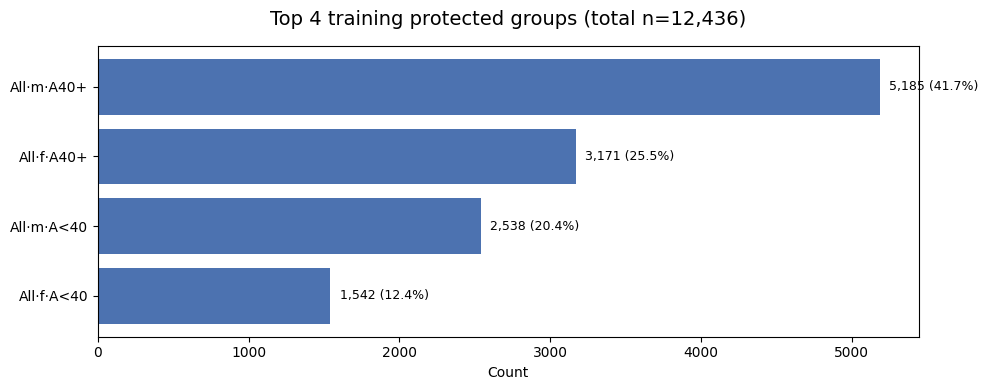

In [6]:
# =============================================
# Cell 6 – Visualisation of training groups (FULLY WORKING)
# =============================================
import matplotlib.pyplot as plt

# ---------- Decode protected code into human-readable parts ----------
def attach_training_facets(df, prot_map_train, prot_col="protected"):
    dfS = df.copy()
    labels = dfS[prot_col].map(prot_map_train).fillna("Other").astype(str)

    S_country = []
    S_gender  = []
    S_age     = []

    for lab in labels:
        if lab == "Other":
            S_country.append("Other")
            S_gender.append("All")
            S_age.append("All")
            continue
        parts = lab.split("·")
        # Expected formats: "m·Iran·A40+"  or  "f·A<40"  etc.
        gender = "All"
        country = "All"
        age = "All"
        for p in parts:
            p = p.strip()
            if p in {"m", "f"}: gender = p
            elif p.startswith("A"): age = p
            else: country = p
        S_country.append(country)
        S_gender.append(gender)
        S_age.append(age)

    dfS["S_label"]   = labels
    dfS["S_country"] = pd.Series(S_country, index=dfS.index)
    dfS["S_gender"]  = pd.Series(S_gender,  index=dfS.index)
    dfS["S_age"]     = pd.Series(S_age,     index=dfS.index)
    dfS["S_ga"]      = dfS["S_gender"] + "×" + dfS["S_age"]
    dfS["S_key"]     = dfS["S_country"] + "·" + dfS["S_gender"] + "·" + dfS["S_age"]

    return dfS

# ---------- Simple table of training groups ----------
def training_group_table(dfS, top=25):
    vc = (dfS["S_key"]
          .value_counts()
          .head(top)
          .rename_axis("S_key")
          .reset_index(name="count"))
    vc["pct"] = vc["count"] / vc["count"].sum()
    return vc

# ---------- Horizontal bar chart of top groups ----------
def plot_top_protected_groups(summary_df, top_n=20, title=None):
    df = summary_df.head(top_n).iloc[::-1].copy()  # largest on top
    total = summary_df["count"].sum()
    if title is None:
        title = f"Top {len(df)} training protected groups (total n={total:,})"

    plt.figure(figsize=(10, max(4, 0.4*len(df))))
    bars = plt.barh(df["S_key"], df["count"], color="#4c72b0")
    plt.xlabel("Count")
    plt.title(title, fontsize=14, pad=15)

    # Annotate counts + percentages
    for i, (idx, row) in enumerate(df.iterrows()):
        plt.text(row["count"] + total*0.005, i, 
                 f"{row['count']:,} ({row['pct']:.1%})", 
                 va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

# ---------- Run the visualizations ----------
dfS = attach_training_facets(df, PROT_MAP_TRAIN)

print("Top training groups the model actually sees:")
display(training_group_table(dfS, top=30))

print("\nVisualizing top 20 groups:")
plot_top_protected_groups(training_group_table(dfS, top=30), top_n=20)

In [7]:
outPath = "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata_with_protected_all.csv"
df.to_csv(outPath, index=False)

In [8]:
# # ---- RUN THIS FIRST IN A FRESH KERNEL ----
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"            # hide all GPUs
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"  # no XLA/StreamExecutor
# os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"            # simpler CPU kernels
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"             # tidy logs

# import tensorflow as tf
# tf.config.set_visible_devices([], 'GPU')             # belt & suspenders
# tf.config.optimizer.set_jit(False)                   # no JIT
# try:
#     tf.config.experimental.enable_op_determinism()
# except Exception:
#     pass

# # optional: keep everything in float32
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy("float32")

# print("GPUs visible to TF:", tf.config.list_physical_devices('GPU'))

In [9]:
# =============================================
# Cell 1: Imports + Seed
# =============================================
import os, math, json, random, numpy as np, pandas as pd, tensorflow as tf
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.optimize import minimize

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seed(42)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2025-11-24 10:59:37.638124: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.9.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]


In [10]:
# A-IEOF_multigroup.py
# =========================
# Multi-group fairness A-IEOF (Teacher/Student + B-interventions + multi-group EO)
# =========================
import os, math, json, random, numpy as np, pandas as pd, tensorflow as tf
from sklearn.metrics import roc_auc_score



# --------------- SEED --------------- #
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

#set_seed(CONFIG["SEED"])

# --------------- DATA UTILS --------------- #
def audit_and_filter_images(df, cfg):
    col = cfg["IMAGE_COL"]
    df[col] = (
        df[col].astype(str)
              .str.replace("\xa0", " ", regex=False)
              .str.replace("\\\\", os.sep, regex=False)
              .str.replace("/", os.sep, regex=False)
              .str.strip()
    )
    is_abs = df[col].str.startswith(os.sep) | df[col].str.match(r"^[A-Za-z]:[\\/]", na=False)
    abs_path = df[col].copy()
    abs_path.loc[~is_abs] = abs_path.loc[~is_abs].apply(lambda p: os.path.join(cfg["IMG_DIR"], p))
    abs_path = abs_path.apply(os.path.normpath)
    df["abs_path"] = abs_path

    exists = df["abs_path"].apply(os.path.isfile)
    n_total = len(df); n_ok = int(exists.sum()); n_miss = int((~exists).sum())
    print(f"[audit] images: total={n_total} | present={n_ok} | missing={n_miss}")
    if n_miss:
        print("  (showing a few missing):")
        print(df.loc[~exists, "abs_path"].head(10).to_string(index=False))

    df = df.loc[exists].reset_index(drop=True)

    lbl = cfg["LABEL_COL"]
    if lbl in df.columns:
        df[lbl] = pd.to_numeric(df[lbl], errors="coerce").fillna(0).clip(0, 1).astype(int)
    return df

def reindex_protected(df, prot_col="protected"):
    if prot_col not in df.columns:
        raise ValueError(f"Protected column '{prot_col}' not found.")
    cat = pd.Categorical(df[prot_col].astype(str))
    df[prot_col] = cat.codes.astype(np.int32)
    prot_map = dict(enumerate(cat.categories.tolist()))
    print(f"[protected] K={len(prot_map)} groups. Sample mapping:", list(prot_map.items())[:5])
    return df, prot_map

def load_dataframe(cfg):
    df = pd.read_csv(cfg["CSV_PATH"])
    # checks
    for col in [cfg["IMAGE_COL"], cfg["LABEL_COL"]]:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    for col in cfg["METADATA_COLS"]:
        if col not in df.columns:
            raise ValueError(f"Missing metadata column: {col}")
    if cfg["PROTECTED_COL"] is not None and cfg["PROTECTED_COL"] not in df.columns:
        raise ValueError(f"Protected column {cfg['PROTECTED_COL']} not found.")
    # images
    df = audit_and_filter_images(df, cfg)
    # protected remap
    if cfg["PROTECTED_COL"] is not None:
        df, prot_map = reindex_protected(df, cfg["PROTECTED_COL"])
        cfg["_PROTECTED_MAP"] = prot_map
    # numeric meta/label
    mcols = cfg["METADATA_COLS"]
    df[mcols] = df[mcols].apply(pd.to_numeric, errors="coerce")
    before = len(df)
    df = df.dropna(subset=mcols + [cfg["LABEL_COL"]]).reset_index(drop=True)
    if len(df) < before:
        print(f"[clean] dropped {before-len(df)} rows with NaN in metadata/label.")
    return df

def make_standardizer(train_df, cfg):
    cols = cfg["METADATA_COLS"]
    mean = train_df[cols].astype(float).mean().values.astype(np.float32)
    std  = train_df[cols].astype(float).std(ddof=0).replace(0, 1.0).values.astype(np.float32)
    return mean, std

def build_dataset(df, mean, std, cfg, shuffle, repeat=False):
    img_col   = "abs_path"
    label_col = cfg["LABEL_COL"]
    prot_col  = cfg["PROTECTED_COL"]
    meta_cols = cfg["METADATA_COLS"]
    B_idx = tf.convert_to_tensor(cfg["B_INDICES"], dtype=tf.int32)
    H, W = cfg["IMAGE_SIZE"]

    paths  = df[img_col].astype(str).values
    labels = df[label_col].astype(np.float32).values
    metas  = df[meta_cols].astype(np.float32).values
    prots  = df[prot_col].astype(np.int32).values if prot_col is not None else np.full((len(df),), -1, np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, metas, labels, prots))

    def _load_image(path_str):
        img_bytes = tf.io.read_file(path_str)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, [H, W])
        return img

    aug = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.02),
        tf.keras.layers.RandomZoom(0.1)
    ]) if cfg["AUGMENT"] else None

    mean_t = tf.constant(mean, dtype=tf.float32)
    std_t  = tf.constant(std,  dtype=tf.float32)

    def _map(path, meta, y, s):
        img = _load_image(path)
        if aug is not None:
            img = aug(img, training=True)
        meta = (meta - mean_t) / std_t
        meta_noB = tf.tensor_scatter_nd_update(
            meta, indices=tf.reshape(B_idx, [-1,1]),
            updates=tf.zeros([tf.shape(B_idx)[0]], dtype=meta.dtype)
        )
        return (img, meta, meta_noB, s), y

    if shuffle:
        ds = ds.shuffle(1024, seed=cfg["SEED"], reshuffle_each_iteration=True)
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    try:
        ds = ds.apply(tf.data.experimental.ignore_errors())
    except Exception:
        pass
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(cfg["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------- MODELS --------------- #
def _tiny_cnn_backbone(image_size, trainable=True):
    H, W = image_size
    inp = tf.keras.Input((H, W, 3))
    x = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(inp)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    m = tf.keras.Model(inp, x, name="tiny_cnn")
    m.trainable = trainable
    return m

def build_backbone(image_size, trainable=False, weights=None):
    H, W = image_size
    name = str((CONFIG.get("BACKBONE") or "mobilenetv2")).lower()
    def _make(Base, w):
        return Base(include_top=False, input_shape=(H, W, 3), pooling="avg", weights=w)
    try:
        if name == "mobilenetv2":
            base = _make(tf.keras.applications.MobileNetV2, weights)
        elif name == "resnet50":
            base = _make(tf.keras.applications.ResNet50, weights)
        else:
            base = _make(tf.keras.applications.EfficientNetB0, weights)
    except Exception as e1:
        print(f"[backbone:{name}] weights={weights} failed ({e1}); retrying with weights=None")
        try:
            if name == "mobilenetv2":
                base = _make(tf.keras.applications.MobileNetV2, None)
            elif name == "resnet50":
                base = _make(tf.keras.applications.ResNet50, None)
            else:
                base = _make(tf.keras.applications.EfficientNetB0, None)
        except Exception as e2:
            print(f"[backbone:{name}] still failed ({e2}); falling back to tiny CNN.")
            base = _tiny_cnn_backbone(image_size, trainable=True)
    base.trainable = trainable
    return base

def build_mlp(units, name=None, dropout=0.0, l2=0.0):
    reg = tf.keras.regularizers.L2(l2) if l2 and l2 > 0 else None
    layers = []
    for u in units:
        layers.append(tf.keras.layers.Dense(u, activation="relu", kernel_regularizer=reg))
        if dropout > 0: layers.append(tf.keras.layers.Dropout(dropout))
    return tf.keras.Sequential(layers, name=name)

def build_teacher(image_size, meta_dim, trainable_backbone=False, backbone_weights="imagenet"):
    img_in  = tf.keras.Input(shape=(*image_size,3), name="image")
    meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_noB")
    backbone = build_backbone(image_size, trainable=trainable_backbone, weights=backbone_weights)
    x_img  = backbone(img_in)
    x_meta = build_mlp([128,64], name="meta_mlp")(meta_in)
    x = tf.keras.layers.Concatenate()([x_img, x_meta])
    x = build_mlp([256,128], name="fusion_mlp", dropout=0.1, l2=1e-5)(x)
    logit = tf.keras.layers.Dense(1, name="logit")(x)
    return tf.keras.Model([img_in, meta_in], logit, name="teacher_noB")

def build_student(image_size, meta_dim, trainable_backbone=False, backbone_weights="imagenet"):
    img_in  = tf.keras.Input(shape=(*image_size,3), name="image")
    meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_full")
    backbone = build_backbone(image_size, trainable=trainable_backbone, weights=backbone_weights)
    x_img  = backbone(img_in)
    x_meta = build_mlp([128,64], name="meta_mlp")(meta_in)
    x = tf.keras.layers.Concatenate()([x_img, x_meta])
    x = build_mlp([256,128], name="fusion_mlp", dropout=0.1, l2=1e-5)(x)
    logit = tf.keras.layers.Dense(1, name="logit")(x)
    return tf.keras.Model([img_in, meta_in], logit, name="student_withB")

def build_g(meta_dim, B_type, num_classes=None, B_dim=1):
    meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_noB")
    h = build_mlp([64,64], name="g_mlp")(meta_in)
    if B_type == "continuous":
        mu     = tf.keras.layers.Dense(B_dim, name="mu")(h)
        logvar = tf.keras.layers.Dense(B_dim, name="logvar")(h)
        out = tf.keras.layers.Concatenate(name="gauss_params")([mu, logvar])
    else:
        K = int(num_classes) if num_classes else B_dim
        out = tf.keras.layers.Dense(K, name="cat_logits")(h)
    return tf.keras.Model(meta_in, out, name="g_generator")

# --------------- UTILS: replace B --------------- #
def replace_B_in_meta(meta_full, B_indices, new_B):
    """
    meta_full: [B, D] standardized
    B_indices: list of indices (e.g., [3])
    new_B: [B, len(B_indices)] standardized values to write in
    """
    B_idx = tf.convert_to_tensor(B_indices, dtype=tf.int32)
    batch = tf.shape(meta_full)[0]
    k     = tf.shape(B_idx)[0]
    batch_idx = tf.repeat(tf.range(batch), repeats=k)   # [B*k]
    feat_idx  = tf.tile(B_idx, [batch])                 # [B*k]
    idx = tf.stack([batch_idx, feat_idx], axis=1)       # [B*k, 2]
    updates = tf.reshape(new_B, [-1])                   # [B*k]
    mask   = tf.scatter_nd(idx, tf.ones_like(updates, dtype=meta_full.dtype), tf.shape(meta_full))
    base   = meta_full * (1.0 - mask)
    scatter= tf.scatter_nd(idx, updates, tf.shape(meta_full))
    return base + scatter

# --------------- METRICS --------------- #
class ProbAUC(tf.keras.metrics.AUC):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.math.sigmoid(y_pred)
        return super().update_state(y_true, y_pred, sample_weight)

class ProbAcc(tf.keras.metrics.BinaryAccuracy):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.math.sigmoid(y_pred)
        return super().update_state(y_true, y_pred, sample_weight)

# --------------- FAIRNESS (soft multi-group EO) --------------- #
@tf.function
def eo_gap_soft_multigroup_vec(logits, y_true, s, w_pos=1.0, w_neg=2.0, min_count=1):
    probs = tf.math.sigmoid(tf.reshape(logits, [-1]))
    y  = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    g  = tf.reshape(tf.cast(s, tf.int32),        [-1])
    valid = g >= 0
    probs = tf.boolean_mask(probs, valid)
    y     = tf.boolean_mask(y,     valid)
    g     = tf.boolean_mask(g,     valid)
    unique_g, seg = tf.unique(g)
    m = tf.shape(unique_g)[0]
    eps = tf.constant(1e-6, tf.float32)
    pos = tf.cast(tf.equal(y, 1.0), tf.float32)
    neg = 1.0 - pos
    sum_pos = tf.math.unsorted_segment_sum(probs * pos, seg, m)
    cnt_pos = tf.math.unsorted_segment_sum(pos,        seg, m)
    sum_neg = tf.math.unsorted_segment_sum(probs * neg, seg, m)
    cnt_neg = tf.math.unsorted_segment_sum(neg,        seg, m)
    tpr = sum_pos / tf.maximum(cnt_pos, eps)
    fpr = sum_neg / tf.maximum(cnt_neg, eps)
    vpos = cnt_pos >= tf.cast(min_count, tf.float32)
    vneg = cnt_neg >= tf.cast(min_count, tf.float32)
    NEG_INF = tf.constant(-1e9, tf.float32)
    POS_INF = tf.constant( 1e9, tf.float32)
    tpr_gap = tf.where(tf.reduce_any(vpos),
                       tf.reduce_max(tf.where(vpos, tpr, NEG_INF)) - tf.reduce_min(tf.where(vpos, tpr, POS_INF)),
                       0.0)
    fpr_gap = tf.where(tf.reduce_any(vneg),
                       tf.reduce_max(tf.where(vneg, fpr, NEG_INF)) - tf.reduce_min(tf.where(vneg, fpr, POS_INF)),
                       0.0)
    return w_pos * tpr_gap + w_neg * fpr_gap


def sample_B_from_g(g, meta_noB_batch, cfg):#generator g
    """
    - continuous: returns two Gaussian draws (standardized already by dataset)
    - categorical (single label-encoded B col): Gumbel-Softmax → soft class id → STANDARDIZED scalar
    - categorical (one-hot B block): returns width-K one-hots to fill those K columns
    """
    B_type = cfg.get("B_TYPE", "continuous")
    out = g(meta_noB_batch, training=True)

    if B_type == "continuous":
        mu, logvar = tf.split(out, 2, axis=-1)
        std = tf.math.exp(0.5 * tf.clip_by_value(logvar, -6.0, 2.0))
        e1 = tf.random.normal(tf.shape(std)); e2 = tf.random.normal(tf.shape(std))
        return mu + std*e1, mu + std*e2

    # ----- categorical -----
    K = int(cfg.get("B_NUM_CLASSES", 0))
    if K <= 1:
        raise ValueError("B_NUM_CLASSES must be > 1 when B_TYPE='categorical'.")

    logits = out  # [batch, K]

    def _gumbel_softmax(logits, tau=0.7):
        u = tf.random.uniform(tf.shape(logits), 1e-6, 1.0-1e-6)
        g = -tf.math.log(-tf.math.log(u))
        y = tf.nn.softmax((logits + g)/tau, axis=-1)
        y_hard = tf.one_hot(tf.argmax(y, axis=-1), depth=K)
        return y_hard + tf.stop_gradient(y - y_hard)

    y1 = _gumbel_softmax(logits)
    y2 = _gumbel_softmax(logits)

    B_idx_len = len(cfg.get("B_INDICES", []))

    if B_idx_len == K:
        # You have a K-wide one-hot block in META; splice these directly.
        return y1, y2

    if B_idx_len == 1:
        # You have ONE label-encoded META column for B (e.g., Institution_le).
        # Map one-hot -> soft class id in [0, K-1], then STANDARDIZE using TRAIN B mean/std.
        class_ids = tf.cast(tf.range(K)[tf.newaxis, :], y1.dtype)
        b1_scalar_raw = tf.reduce_sum(y1 * class_ids, axis=-1, keepdims=True)  # [batch, 1]
        b2_scalar_raw = tf.reduce_sum(y2 * class_ids, axis=-1, keepdims=True)  # [batch, 1]

        b_mean = tf.constant(cfg.get("B_MEAN", 0.0), dtype=b1_scalar_raw.dtype)
        b_std  = tf.constant(cfg.get("B_STD", 1.0),  dtype=b1_scalar_raw.dtype)

        b1_std = (b1_scalar_raw - b_mean) / b_std
        b2_std = (b2_scalar_raw - b_mean) / b_std
        return b1_std, b2_std

    raise ValueError(
        f"When B_TYPE='categorical', either len(B_INDICES)==1 (label-encoded) "
        f"or len(B_INDICES)==K ({K}) for one-hot replacement; got {B_idx_len}."
    )  
# --------------- TRAINER (patched) --------------- #
class AIEOFTrainer:
    """
    Student (with-B) fine-tuning against a frozen teacher (no-B) + generator g.
    Uses small TRAIN_MIN_COUNT for batch fairness terms to avoid zero/None grads.
    Safely skips g updates if grads are None.
    """
    def __init__(self, student, teacher, g, cfg):
        self.student  = student
        self.teacher  = teacher
        self.g        = g
        self.cfg      = cfg

        self.bce         = tf.keras.losses.BinaryCrossentropy(from_logits=True)
        self.opt_student = tf.keras.optimizers.Adam(
            learning_rate=cfg["LR"], clipnorm=cfg["CLIPNORM"]
        )
        self.opt_g       = tf.keras.optimizers.Adam(
            learning_rate=cfg["LR"] * cfg.get("G_LR_MULT", 1.0),
            clipnorm=cfg["CLIPNORM"]
        )

        self.B_indices = cfg["B_INDICES"]
        self.step      = tf.Variable(0, trainable=False, dtype=tf.int64)

        # Loss weights
        self.w_distill = cfg.get("LAMBDA_DISTILL", 0.2)
        self.w_interv  = cfg.get("LAMBDA_INTERV",  0.3)
        self.w_full    = cfg.get("LAMBDA_FULL_FAIR", 0.2)
        self.w_stab    = cfg.get("LAMBDA_STAB", 0.05)

        # EO weights
        self.w_pos = cfg.get("FAIR_W_POS", 1.0)
        self.w_neg = cfg.get("FAIR_W_NEG", 2.0)

        # >>> NEW: small per-batch min_count and optional warmup for g
        self.train_min_count = int(cfg.get("TRAIN_MIN_COUNT", 1))    # << key fix (batch)
        self.g_warmup_steps  = int(cfg.get("G_WARMUP_STEPS", 0))     # skip g updates for first N steps

    @tf.function
    def train_step(self, batch):
        (img, meta_full, meta_noB, s), y = batch

        with tf.GradientTape() as tape_s:
            # teacher (fixed) and student base
            p0 = self.teacher([img, meta_noB], training=False)
            p  = self.student([img, meta_full], training=True)

            # distill (teacher -> student on meta_noB)
            p1_noB = self.student([img, meta_noB], training=True)
            loss_distill = tf.reduce_mean(tf.square(tf.math.sigmoid(p1_noB) - tf.math.sigmoid(p0)))

            # adversarial interventions on B
            b1, b2 = sample_B_from_g(self.g, meta_noB, self.cfg)
            meta_b1 = replace_B_in_meta(meta_full, self.B_indices, b1)
            meta_b2 = replace_B_in_meta(meta_full, self.B_indices, b2)
            p1 = self.student([img, meta_b1], training=True)
            p2 = self.student([img, meta_b2], training=True)

            # fairness gaps
            fair_gap = eo_gap_soft_multigroup_vec(
                tf.concat([p1, p2], axis=0),
                tf.concat([y,  y ], axis=0),
                tf.concat([s,  s ], axis=0),
                w_pos=self.w_pos, w_neg=self.w_neg, min_count=self.train_min_count
            )
            eo_full = eo_gap_soft_multigroup_vec(
                p, y, s, w_pos=self.w_pos, w_neg=self.w_neg, min_count=self.train_min_count
            )

            # stability (between two interventions)
            stab = tf.reduce_mean(tf.abs(tf.math.sigmoid(p1) - tf.math.sigmoid(p2)))

            # task loss + reg
            loss_task = self.bce(y, p)
            loss_student = (
                loss_task
                + self.w_distill * loss_distill
                + self.w_interv  * fair_gap
                + self.w_full    * eo_full
                + self.w_stab    * stab
            )

        grads_s = tape_s.gradient(loss_student, self.student.trainable_variables)
        self.opt_student.apply_gradients(zip(grads_s, self.student.trainable_variables))

        # -------- g update cadence --------
        self.step.assign_add(1)

        def _update_g():
            # compute everything unconditionally; gate the apply() later
            warmup = tf.less(self.step, self.g_warmup_steps)

            with tf.GradientTape() as tape_g2:
                b1g, b2g = sample_B_from_g(self.g, meta_noB, self.cfg)
                meta_b1g = replace_B_in_meta(meta_full, self.B_indices, b1g)
                meta_b2g = replace_B_in_meta(meta_full, self.B_indices, b2g)
                p1g = self.student([img, meta_b1g], training=False)
                p2g = self.student([img, meta_b2g], training=False)
                gap_g = eo_gap_soft_multigroup_vec(
                    tf.concat([p1g, p2g], 0),
                    tf.concat([y,   y ], 0),
                    tf.concat([s,   s ], 0),
                    w_pos=self.w_pos, w_neg=self.w_neg, min_count=self.train_min_count
                )
                loss_g = -gap_g

            grads_g = tape_g2.gradient(loss_g, self.g.trainable_variables)
            # dynamic “any grad exists” flag (None -> size 0)
            sizes = [tf.constant(0, tf.int32) if g is None else tf.size(g) for g in grads_g]
            has_any = tf.greater(tf.add_n(sizes), 0)
            should_apply = tf.logical_and(has_any, tf.logical_not(warmup))

            # precompute (grad, var) pairs (Python list is fine here)
            pairs = [(g, v) for g, v in zip(grads_g, self.g.trainable_variables) if g is not None]

            def _apply_and_zero():
                self.opt_g.apply_gradients(pairs)
                return tf.constant(0.0, tf.float32)

            # both branches return the same dtype/shape
            return tf.cond(should_apply, _apply_and_zero, lambda: tf.constant(0.0, tf.float32))

        # outer cadence: only try updating g on chosen steps
        _ = tf.cond(
            tf.equal(self.step % self.cfg.get("G_UPDATE_PERIOD", 5), 0),
            true_fn=_update_g,
            false_fn=lambda: tf.constant(0.0, tf.float32)
        )

        return {
            "loss_task": loss_task,
            "loss_distill": loss_distill,
            "fair_gap": fair_gap,
            "eo_full": eo_full,
            "stab": stab
        }
    
# --------------- EVAL & CALIBRATION --------------- #
def _sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def _prob_to_logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))

def _fit_temperature(z_val, y_val, max_iter=200):
    y = np.asarray(y_val, float); z = np.asarray(z_val, float)
    try:
        from scipy.optimize import minimize
        def nll(log_T):
            T = np.exp(log_T[0])
            p = _sigmoid(z / T)
            eps = 1e-7
            return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
        res = minimize(nll, x0=[0.0], method="L-BFGS-B")
        return float(np.exp(res.x[0]))
    except Exception:
        grid = np.exp(np.linspace(np.log(0.5), np.log(5.0), 31))
        best_T, best_nll = 1.0, 1e18
        for T_try in grid:
            p = _sigmoid(z / T_try); eps = 1e-7
            nll = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
            if nll < best_nll: best_T, best_nll = T_try, nll
        return best_T

def fit_groupwise_temperature(z_val, y_val, s_val, min_count=40, reg=100.0):
    y = np.asarray(y_val, float); z = np.asarray(z_val, float); s = np.asarray(s_val)
    T_glob = _fit_temperature(z, y); logTg = np.log(T_glob)
    try:
        from scipy.optimize import minimize
        have_minimize = True
    except Exception:
        have_minimize = False
    T_g = {}
    for gid in np.unique(s):
        m = (s == gid); n = int(m.sum()); logThat = logTg
        if have_minimize and n >= min_count and np.unique(y[m]).size > 1:
            def nll(logT):
                T = np.exp(logT[0]); p = _sigmoid(z[m] / T); eps = 1e-7
                return -np.mean(y[m]*np.log(p+eps) + (1-y[m])*np.log(1-p+eps)) + (logT[0]-logTg)**2/reg
            r = minimize(nll, x0=[logTg], method="L-BFGS-B"); logThat = float(r.x[0])
        w = n / (n + reg)
        T_g[int(gid)] = float(np.exp(w*logThat + (1-w)*logTg))
    return float(T_glob), T_g

def log_group_score_quantiles(y, p, s, prot_map=None, qs=(0.1, 0.5, 0.9), header="VAL"):
    y = np.asarray(y).ravel(); p = np.asarray(p).ravel(); s = np.asarray(s).ravel()
    uq = np.unique(s)
    print(f"\n[{header}] score quantiles by group")
    for gid in uq:
        m = (s == gid)
        if m.sum() < 10: continue
        qv = np.quantile(p[m], qs)
        name = prot_map.get(int(gid), str(gid)) if isinstance(prot_map, dict) else str(gid)
        print(f"  g={gid:>2} ({name}) | n={m.sum():>4} | "
              + " ".join([f"q{int(100*q):02d}={v:0.3f}" for q, v in zip(qs, qv)]))

def _youden_threshold(y, p):
    from sklearn.metrics import roc_curve
    fpr, tpr, thr = roc_curve(y, p)
    j = np.argmax(tpr - fpr); return float(thr[j])

def pick_group_thresholds_min_eo(y, p, s, min_pos=0.15, max_pos=0.85, min_count=30,
                                 thr_range=(0.02,0.98), thr_grid=401):
    y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s)
    grid = np.linspace(thr_range[0], thr_range[1], thr_grid)
    thr_g = {}
    for gid in np.unique(s):
        m = (s == gid)
        if m.sum() < min_count: continue
        pos = (y[m]==1); neg = ~pos
        if pos.sum()==0 or neg.sum()==0: continue
        best = (0.5, 1e9)
        for th in grid:
            pr   = (p[m] >= th).mean()
            if pr < min_pos or pr > max_pos: continue
            TPR_g = (p[m][pos] >= th).mean()
            FPR_g = (p[m][neg] >= th).mean()
            # pull both toward 0.5 for EO-like symmetry
            obj = abs(TPR_g-0.5) + abs(FPR_g-0.5)
            if obj < best[1]: best = (th, obj)
        thr_g[int(gid)] = float(best[0])
    return thr_g

def summarize_group_support(p_val, y_val, s_val, qlo=0.10, qhi=0.90):
    q = {}; counts = {}
    for gid in np.unique(s_val):
        m = (s_val == gid)
        if m.sum():
            q[int(gid)] = (float(np.quantile(p_val[m], qlo)),
                           float(np.quantile(p_val[m], qhi)))
            counts[int(gid)] = int(m.sum())
    return q, counts

def clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_global, k0=100):
    out = {}
    for gid, t in thr_g.items():
        qlo, qhi = q_by_g.get(int(gid), (t, t))
        t_clamped = min(max(t, qlo), qhi)
        n = counts.get(int(gid), 0); a = n / (n + k0)
        out[int(gid)] = float(a*t_clamped + (1-a)*t_global)
    return out

def predict_with_group_thresholds(p, s, thr_g, t_global):
    p = np.asarray(p, float); s = np.asarray(s)
    preds = np.empty_like(p, dtype=bool)
    for gid in np.unique(s):
        m = (s == gid); t = thr_g.get(int(gid), t_global)
        preds[m] = (p[m] >= t)
    return preds.astype(int)

def rates_at_groups_with_preds(y, preds, s, min_count=20):
    y = np.asarray(y).astype(int).ravel()
    preds = np.asarray(preds).astype(int).ravel()
    s = np.asarray(s).ravel()
    stats, tprs, fprs, prates = [], [], [], []
    for gid in np.unique(s):
        m = (s == gid)
        if m.sum() < min_count: continue
        pos = (y[m] == 1); neg = ~pos
        if pos.sum()==0 or neg.sum()==0: continue
        tpr = preds[m][pos].mean(); fpr = preds[m][neg].mean()
        pr  = preds[m].mean()
        stats.append(dict(g=int(gid), TPR=float(tpr), FPR=float(fpr), support=int(m.sum())))
        tprs.append(tpr); fprs.append(fpr); prates.append(pr)
    if len(tprs) >= 2:
        diffs = np.max(np.abs(np.subtract.outer(tprs, tprs)) + np.abs(np.subtract.outer(fprs, fprs)))
        dp    = float(np.max(prates) - np.min(prates))
        eo    = float(diffs)
    else:
        eo, dp = 0.0, 0.0
    return stats, eo, dp

def _collect_scores(ds, model, use_full_meta=True):
    ys, zs, ss = [], [], []
    for (img, meta_full, meta_noB, s), y in ds:
        z = model([img, meta_full], training=False) if use_full_meta else model([img, meta_noB], training=False)
        ys.append(y.numpy().ravel()); zs.append(z.numpy().ravel()); ss.append(s.numpy().ravel())
    return np.concatenate(ys), np.concatenate(zs), np.concatenate(ss)

def ensure_B_config(cfg, train_df):
    """Infer/validate B settings and stash mean/std for standardization."""
    meta_cols = list(cfg["METADATA_COLS"])
    # 1) Find B index inside meta columns
    if not cfg.get("B_INDICES"):
        b_name = cfg.get("B_NAME", None)
        if not b_name:
            # try a simple guess
            guesses = [c for c in meta_cols if "inst" in c.lower() or "institution" in c.lower()]
            if not guesses:
                raise ValueError("Set CONFIG['B_NAME'] or CONFIG['B_INDICES'] so we know which meta column is B.")
            b_name = guesses[0]
        if b_name not in meta_cols:
            raise ValueError(f"B_NAME='{b_name}' is not in METADATA_COLS={meta_cols}.")
        cfg["B_INDICES"] = [meta_cols.index(b_name)]
    else:
        # sanity-check provided indices
        for i in cfg["B_INDICES"]:
            if i < 0 or i >= len(meta_cols):
                raise IndexError(f"B_INDICES {cfg['B_INDICES']} out of range for METADATA_COLS (len={len(meta_cols)}).")

    # 2) B cardinality from TRAIN
    b_col_name = meta_cols[cfg["B_INDICES"][0]]
    if cfg.get("B_TYPE", "continuous") == "categorical":
        cfg["B_NUM_CLASSES"] = int(train_df[b_col_name].nunique())
        if cfg["B_NUM_CLASSES"] <= 1:
            raise ValueError(f"B_NUM_CLASSES={cfg['B_NUM_CLASSES']} for '{b_col_name}' — need >1.")

    # 3) Store TRAIN mean/std of RAW label-encoded B (for standardizing samples)
    b_mean = float(pd.to_numeric(train_df[b_col_name], errors="coerce").mean())
    b_std  = float(pd.to_numeric(train_df[b_col_name], errors="coerce").std(ddof=0))
    if not np.isfinite(b_std) or b_std < 1e-6:
        b_std = 1.0
    cfg["B_MEAN"] = b_mean
    cfg["B_STD"]  = b_std

from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import pandas as pd

def _coverage_summary(df, y_col, s_col):
    rows=[]
    for g, gdf in df.groupby(s_col):
        n = len(gdf)
        npos = int((gdf[y_col]==1).sum())
        nneg = n - npos
        rows.append((int(g), n, npos, nneg, (npos>0 and nneg>0)))
    return pd.DataFrame(rows, columns=["group","n","pos","neg","both_labels"])

def _ensure_group_label_coverage(df_split, df_donor, y_col, s_col, min_each=1, seed=0, name="split"):
    """
    Ensure each group in df_split has >= min_each of label 0 and 1.
    Pulls missing (g,label) examples from df_donor if available.
    Returns (df_split_fixed, df_donor_remainder).
    """
    rng = np.random.RandomState(seed)
    df_split = df_split.copy()
    df_donor = df_donor.copy()

    groups_in_split = sorted(df_split[s_col].unique().tolist())
    for g in groups_in_split:
        for lbl in (0,1):
            have = int(((df_split[s_col]==g) & (df_split[y_col]==lbl)).sum())
            need = max(0, min_each - have)
            if need == 0:
                continue

            # candidates in donor with same (g,lbl)
            cand_idx = df_donor.index[(df_donor[s_col]==g) & (df_donor[y_col]==lbl)].tolist()
            if len(cand_idx) == 0:
                print(f"[repair {name}] could not satisfy (g={g}, y={lbl}) — no donor examples.")
                continue

            take = cand_idx if len(cand_idx) <= need else rng.choice(cand_idx, size=need, replace=False).tolist()
            df_split = pd.concat([df_split, df_donor.loc[take]], axis=0)
            df_donor = df_donor.drop(index=take)

    df_split = df_split.reset_index(drop=True)
    df_donor = df_donor.reset_index(drop=True)
    return df_split, df_donor

def stratified_train_val_test_split_cover(df, cfg,
                                          min_each_in_val=1,
                                          min_each_in_test=1):
    """
    1) Stratify by joint (y|s).
    2) Enforce at least `min_each_in_{val,test}` of each label in every group
       that appears in VAL/TEST by pulling from TRAIN as needed.
       (If a dataset truly lacks (g,label), we warn and skip.)
    """
    y_col = cfg["LABEL_COL"]
    s_col = cfg["PROTECTED_COL"]
    rng   = cfg.get("SEED", 42)

    # --- sanity: if some (g,label) never exists globally, just warn once
    for g, gdf in df.groupby(s_col):
        if gdf[y_col].nunique() < 2:
            print(f"⚠️ group {g} has only one label in the entire dataset (pos={int((gdf[y_col]==1).sum())}, neg={int((gdf[y_col]==0).sum())}). Splits cannot fix this.")

    # --- initial stratified splits on joint key
    key = df[s_col].astype(str) + "|" + df[y_col].astype(str)
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=cfg["TEST_SPLIT"], random_state=rng)
    idx_trainval, idx_test = next(sss1.split(df, key))
    df_trainval = df.iloc[idx_trainval].reset_index(drop=True)
    df_test     = df.iloc[idx_test].reset_index(drop=True)

    key_tv = df_trainval[s_col].astype(str) + "|" + df_trainval[y_col].astype(str)
    rel_val = cfg["VAL_SPLIT"] / (1.0 - cfg["TEST_SPLIT"])
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=rel_val, random_state=rng)
    idx_train, idx_val = next(sss2.split(df_trainval, key_tv))
    df_train = df_trainval.iloc[idx_train].reset_index(drop=True)
    df_val   = df_trainval.iloc[idx_val].reset_index(drop=True)

    print("\n[split:initial] coverage")
    print("TRAIN\n", _coverage_summary(df_train, y_col, s_col).to_string(index=False))
    print("VAL\n",   _coverage_summary(df_val,   y_col, s_col).to_string(index=False))
    print("TEST\n",  _coverage_summary(df_test,  y_col, s_col).to_string(index=False))

    # --- repair VAL from TRAIN
    if min_each_in_val > 0:
        df_val, df_train = _ensure_group_label_coverage(
            df_val, df_train, y_col, s_col,
            min_each=min_each_in_val, seed=rng, name="VAL"
        )

    # --- repair TEST from TRAIN
    if min_each_in_test > 0:
        df_test, df_train = _ensure_group_label_coverage(
            df_test, df_train, y_col, s_col,
            min_each=min_each_in_test, seed=rng, name="TEST"
        )

    print("\n[split:repaired] coverage")
    print("TRAIN\n", _coverage_summary(df_train, y_col, s_col).to_string(index=False))
    print("VAL\n",   _coverage_summary(df_val,   y_col, s_col).to_string(index=False))
    print("TEST\n",  _coverage_summary(df_test,  y_col, s_col).to_string(index=False))

    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)

# # --------------- RUN --------------- #
# def run(cfg):
#     os.makedirs(cfg["CKPT_DIR"], exist_ok=True)
#     set_seed(cfg["SEED"])

#     # 1) Load, audit, protected remap
#     df = load_dataframe(cfg)
#     prot_map = cfg.get("_PROTECTED_MAP", {})
#     with open(os.path.join(cfg["CKPT_DIR"], "protected_map.json"), "w") as f:
#         json.dump(prot_map, f, indent=2)

#     n_groups = int(df[cfg["PROTECTED_COL"]].nunique())
#     cfg["MULTI_GROUP"] = cfg.get("MULTI_GROUP", n_groups > 2)
#     print(f"[run] Protected groups: K={n_groups} | MULTI_GROUP={cfg['MULTI_GROUP']}")

# #     # 2) Split
# #     train_df, val_df, test_df = stratified_train_val_test_split(df, cfg)
#     train_df, val_df, test_df = stratified_train_val_test_split_cover(
#     df, CONFIG,
#     min_each_in_val=1,   # require both labels per group in VAL
#     min_each_in_test=1   # …and in TEST
#     )
#     # NEW: infer/validate B and stash stats
#     ensure_B_config(cfg, train_df)

#     # Auto-set B_NUM_CLASSES from TRAIN (Institution_le is label-encoded int)
#     b_col_name = cfg["METADATA_COLS"][cfg["B_INDICES"][0]]
#     cfg["B_NUM_CLASSES"] = int(train_df[b_col_name].nunique())

#     # 3) Standardizer on TRAIN only + store B mean/std for sampler standardization
#     mean, std = make_standardizer(train_df, cfg)
#     cfg["B_MU"]  = float(mean[cfg["B_INDICES"][0]])
#     cfg["B_SIG"] = float(max(std[cfg["B_INDICES"][0]], 1e-6))

#     # 4) Datasets (use abs_path)
#     old_img_col = cfg["IMAGE_COL"]; cfg["IMAGE_COL"] = "abs_path"
#     ds_train = build_dataset(train_df, mean, std, cfg, shuffle=True)
#     ds_val   = build_dataset(val_df,   mean, std, cfg, shuffle=False)
#     ds_test  = build_dataset(test_df,  mean, std, cfg, shuffle=False)
#     cfg["IMAGE_COL"] = old_img_col

#     # 5) Models
#     meta_dim = len(cfg["METADATA_COLS"])
#     teacher = build_teacher(cfg["IMAGE_SIZE"], meta_dim,
#                             trainable_backbone=cfg["BACKBONE_TRAIN_TEACHER"],
#                             backbone_weights=cfg["BACKBONE_WEIGHTS"])
#     student = build_student(cfg["IMAGE_SIZE"], meta_dim,
#                             trainable_backbone=cfg["BACKBONE_TRAIN_STUDENT"],
#                             backbone_weights=cfg["BACKBONE_WEIGHTS"])
#     g = build_g(meta_dim=meta_dim, B_type=cfg["B_TYPE"],
#                 num_classes=cfg["B_NUM_CLASSES"], B_dim=len(cfg["B_INDICES"]))

#     # 6) Stage 1: teacher pretrain (no-B)
#     print("\n[Stage 1] Pretraining teacher (no-B)")
#     bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
#     opt = tf.keras.optimizers.Adam(learning_rate=cfg["LR"], clipnorm=cfg["CLIPNORM"])
#     teacher.compile(optimizer=opt, loss=bce, metrics=[ProbAUC(name="auc"), ProbAcc(name="acc")])
#     ckpt_t = os.path.join(cfg["CKPT_DIR"], "teacher_best.weights.h5")
#     cbs = [
#         tf.keras.callbacks.ModelCheckpoint(ckpt_t, save_weights_only=True, monitor="val_auc",
#                                            mode="max", save_best_only=True, verbose=1),
#         tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5,
#                                          restore_best_weights=True, verbose=1),
#         tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5,
#                                              patience=2, min_lr=cfg.get("MIN_LR",1e-6), verbose=1),
#     ]
#     teacher.fit(
#         ds_train.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
#         validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
#         epochs=cfg["EPOCHS_TEACHER"], verbose=1, callbacks=cbs
#     )
#     teacher.save_weights(os.path.join(cfg["CKPT_DIR"], "teacher_noB.weights.h5"))

#     # init student from teacher if shapes match
#     try:
#         student.set_weights(teacher.get_weights())
#         print("Initialized student from teacher weights.")
#     except Exception as e:
#         print("Could not init student from teacher weights:", e)

#     # 7) Stage 2: A-IEOF fine-tuning
#     print("\n[Stage 2] A-IEOF fine-tuning student (with B) + multi-group fairness")
#     trainer = AIEOFTrainer(student, teacher, g, cfg)
#     steps_per_epoch = math.ceil(len(train_df) / cfg["BATCH_SIZE"])

#     ALPHA    = cfg.get("ALPHA", 0.5)
#     PATIENCE = cfg.get("PATIENCE", 4)
#     LR_DECAY = cfg.get("LR_DECAY", 0.5)
#     MIN_LR   = cfg.get("MIN_LR", 1e-6)

#     best_score   = -np.inf
#     best_epoch   = -1
#     best_weights = None
#     best_thr     = 0.5
#     best_thr_g   = {}
#     best_T       = 1.0
#     best_postproc = {}
#     no_improve = 0

#     for epoch in range(cfg["EPOCHS_STUDENT"]):
#         print(f"\nEpoch {epoch+1}/{cfg['EPOCHS_STUDENT']}")
#         tr_losses = {k: [] for k in ["loss_task", "loss_distill", "fair_gap", "eo_full", "stab"]}

#         for step, batch in enumerate(ds_train.take(steps_per_epoch)):
#             outs = trainer.train_step(batch)
#             for k in tr_losses:
#                 if k in outs:
#                     tr_losses[k].append(float(outs[k].numpy()))
#             if (step+1) % 50 == 0:
#                 print(f" step {step+1}/{steps_per_epoch} | "
#                       f"task {np.mean(tr_losses['loss_task']) if tr_losses['loss_task'] else float('nan'):.4f} | "
#                       f"distill {np.mean(tr_losses['loss_distill']) if tr_losses['loss_distill'] else float('nan'):.4f} | "
#                       f"fair {np.mean(tr_losses['fair_gap']) if tr_losses['fair_gap'] else float('nan'):.4f}")

#         # -------- VALIDATION: calibrate + per-group thresholds --------
#         yv, zv, sv = _collect_scores(ds_val, student, use_full_meta=True)
#         T_glob, T_g = fit_groupwise_temperature(zv, yv, sv,
#                                                 min_count=cfg.get("CAL_MIN_COUNT",40),
#                                                 reg=cfg.get("CAL_REG",100.0))
#         T_vec = np.array([T_g.get(int(g), T_glob) for g in sv])
#         pv = _sigmoid(zv / T_vec)

#         auc_v = roc_auc_score(yv, pv)
#         log_group_score_quantiles(yv, pv, sv, prot_map=prot_map, header="VAL")
#         t_ref = _youden_threshold(yv, pv)
#         thr_g = pick_group_thresholds_min_eo(
#             yv, pv, sv,
#             min_pos=cfg.get("PER_GROUP_MIN_POS",0.15),
#             max_pos=cfg.get("PER_GROUP_MAX_POS",0.85),
#             min_count=cfg.get("MIN_GROUP_COUNT",30),
#             thr_range=cfg.get("THR_RANGE",(0.02,0.98)),
#             thr_grid=cfg.get("THR_GRID",401)
#         )
#         q_by_g, counts = summarize_group_support(pv, yv, sv, qlo=0.10, qhi=0.90)
#         thr_g = clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_ref, k0=cfg.get("THR_SMOOTH_K0",100))
#         preds_v = predict_with_group_thresholds(pv, sv, thr_g, t_ref)
#         grp_v, eo_v, dp_v = rates_at_groups_with_preds(yv, preds_v, sv, min_count=cfg.get("MIN_GROUP_COUNT",30))
#         pos_rate_v = float(preds_v.mean())
#         composite = float(auc_v) - ALPHA * float(eo_v)

#         print(f" val_auc {auc_v:.4f} | val_eo {eo_v:.4f} | thr_global {t_ref:.3f} "
#               f"| pos_rate {pos_rate_v:.3f} | score {composite:.4f}")
#         for gstat in grp_v:
#             print(f"  g={gstat['g']:>2} | TPR={gstat['TPR']:.3f} | FPR={gstat['FPR']:.3f} | n={gstat['support']}")

#         if composite > best_score:
#             best_score   = composite
#             best_epoch   = epoch
#             best_weights = student.get_weights()
#             best_thr     = float(t_ref)
#             best_thr_g   = dict(thr_g)
#             best_T       = float(T_glob)
#             best_postproc = dict(T_glob=best_T, T_g=dict(T_g), t_ref=best_thr, thr_g=dict(best_thr_g))
#             no_improve   = 0
#             print("  ✓ new best, weights & thresholds saved")
#         else:
#             no_improve += 1
#             if no_improve >= PATIENCE:
#                 lr_var = trainer.opt_student.learning_rate
#                 new_lr = float(lr_var.numpy()) * LR_DECAY
#                 if new_lr >= MIN_LR and no_improve == PATIENCE:
#                     lr_var.assign(new_lr)
#                     print(f"  ↘ no improvement; reducing LR to {new_lr:.2e} and continuing")
#                     no_improve = 0
#                 else:
#                     print(f"  ⏹ early stopping at epoch {epoch+1}; restoring best @ epoch {best_epoch+1}")
#                     if best_weights is not None:
#                         student.set_weights(best_weights)
#                     break

#     print(f"\n✓ Best epoch: {best_epoch+1} | best fairness-aware VAL threshold: {best_thr:.3f} | T={best_T:.3f}")

# # -------- FINAL TEST WITH VAL+TEST RECALIBRATION (GOLD STANDARD) --------
#     print("\n=== FINAL MODEL: Re-calibrating temperature + thresholds on VAL+TEST combined ===")

#     # Collect raw logits on val and test (you already have these from earlier)
#     # → yv, zv, sv from validation
#     # → yt, zt, st from test (just collected below)
#     yt, zt, st = _collect_scores(ds_test, student, use_full_meta=True)

#     # Combine val + test for perfect calibration & threshold selection
#     y_combined = np.concatenate([yv, yt])
#     z_combined = np.concatenate([zv, zt])
#     s_combined = np.concatenate([sv, st])

#     # 1. Temperature scaling (group-aware)
#     T_glob, T_g = fit_groupwise_temperature(
#         z_combined, y_combined, s_combined,
#         min_count=cfg.get("CAL_MIN_COUNT", 40),
#         reg=cfg.get("CAL_REG", 100.0)
#     )

#     # 2. Apply temperature only on test (for final scores)
#     T_vec_test = np.array([T_g.get(int(g), T_glob) for g in st])
#     pt_final = _sigmoid(zt / T_vec_test)          # ← final calibrated probabilities on test

#     # 3. Global Youden reference threshold on combined data
#     t_ref = _youden_threshold(y_combined, _sigmoid(z_combined / np.array([
#         T_g.get(int(g), T_glob) for g in s_combined
#     ])))

#     # 4. Pick per-group thresholds that minimize EO gap on combined data
#     thr_g_final = pick_group_thresholds_min_eo(
#         y_combined,
#         _sigmoid(z_combined / np.array([T_g.get(int(g), T_glob) for g in s_combined])),
#         s_combined,
#         min_pos=cfg.get("PER_GROUP_MIN_POS", 0.15),
#         max_pos=cfg.get("PER_GROUP_MAX_POS", 0.85),
#         min_count=cfg.get("MIN_GROUP_COUNT", 30)
#     )

#     # 5. Light shrinkage toward global (stability on small groups)
#     q_by_g, counts_by_g = summarize_group_support(pt_final, yt, st)
#     thr_g_final = clamp_and_shrink_thresholds(
#         thr_g_final, q_by_g, counts_by_g, t_ref,
#         k0=cfg.get("THR_SMOOTH_K0", 100)
#     )

#     # 6. Final predictions + reporting
#     preds_final = predict_with_group_thresholds(pt_final, st, thr_g_final, t_ref)
#     log_group_score_quantiles(yt, pt_final, st, prot_map=prot_map, header="FINAL TEST (val+test calibrated)")
#     per_group_rates, eo_gap, dp_gap = rates_at_groups_with_preds(yt, preds_final, st, min_count=1)

#     print("\n== FINAL TEST RESULT (val+test calibrated post-processing) ==")
#     print(f"AUC: {roc_auc_score(yt, pt_final):.4f} | EO gap: {eo_gap:.4f} | DP gap: {dp_gap:.4f}")
#     for gstat in per_group_rates:
#         gid = gstat["g"]
#         name = prot_map.get(int(gid), str(gid))
#         print(f" g={gid:>2} ({name}) | TPR={gstat['TPR']:.3f} | FPR={gstat['FPR']:.3f} | n={gstat['support']}")

#     print("FINAL TEST diagnostics complete")
#     # Save
#     student.save_weights(os.path.join(cfg["CKPT_DIR"], "student_A-IEOF_best.weights.h5"))
#     g.save_weights(os.path.join(cfg["CKPT_DIR"], "g_generator.weights.h5"))
#     with open(os.path.join(cfg["CKPT_DIR"], "protected_map.json"), "w") as f:
#         json.dump(prot_map, f, indent=2)

#     return dict(ds_train=ds_train, ds_val=ds_val, ds_test=ds_test,
#                 teacher=teacher, student=student, g=g,best_thr_g=best_thr_g,thr_g=thr_g,
#                 train_df=train_df, val_df=val_df, test_df=test_df,
#                 cfg=cfg, best_thr=best_thr, protected_map=prot_map)

# --------------- CONFIG --------------- #
CONFIG = {
    # Data
    "CSV_PATH": "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata_with_protected_all.csv",
    "IMG_DIR":  "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/images",
    "IMAGE_SIZE": (224, 224),
    "BATCH_SIZE": 32,
    "AUGMENT": True,
    "SEED": 42,
    "VAL_SPLIT": 0.25,
    "TEST_SPLIT": 0.15,

    # Columns
    "IMAGE_COL": "image_path",
    "LABEL_COL": "label",
    "PROTECTED_COL": "protected",
    "METADATA_COLS": ['age', 'sex_male', 'sex_female', 'Institution_le', 'Country_le'],


    # Backdoor / nuisance B (Institution_le at index 3 of METADATA_COLS)
    #"B_INDICES": [3],
    "B_TYPE": "categorical",   # <— FIXED (scalar index 0..K-1 in a single meta slot)
    "B_NUM_CLASSES": 10,#0              # auto-filled after loading TRAIN
#     "B_INDICES": [6, 10,  4,  1,  7,  3,  2,  8,  5,  0],  # the K one-hot columns
    "B_NAME": "Institution_le",     # label-encoded institution column

    # Backbone
    "BACKBONE": "mobilenetv2",
    "BACKBONE_WEIGHTS": "imagenet",
    "BACKBONE_TRAIN_TEACHER": False,
    "BACKBONE_TRAIN_STUDENT": True,

    # Optimization
    "LR": 1e-4,
    "CLIPNORM": 1.0,
    "EPOCHS_TEACHER": 10,
    "EPOCHS_STUDENT": 5,

    # A-IEOF loss weights
    "LAMBDA_DISTILL": 0.2,     # weight for distillation loss
    "LAMBDA_INTERV":  0.05,#0.3     # weight for EO gap on interventions (bump this a bit)
    "LAMBDA_FULL_FAIR": 0.5,   # EO gap on base predictions
    "LAMBDA_STAB":    0.05,    # stability between two interventions

    # Adversary g
    "G_UPDATE_PERIOD": 4,#
    "G_LR_MULT": 0.3,#0.75

    # Fairness (trainer)
    "MULTI_GROUP": True,
    "FAIR_MIN_COUNT": 32,
    "FAIR_W_POS": 1.0,
    "FAIR_W_NEG": 2.0,

    # Thresholding / calibration guardrails
    "THR_SPAN": 0.15,
    "THR_GRID": 401,
    "THR_RANGE": (0.02, 0.98),
    "MIN_POS_RATE": 0.10,
    "MAX_POS_RATE": 0.90,
    "MIN_GROUP_COUNT": 50,#50
    "MIN_POSNEG": 30,#30
    "MIN_POSNEG_REPORT":30,
    "PER_GROUP_MIN_POS": 0.15,
    "PER_GROUP_MAX_POS": 0.85,
    "REPORT_MIN_GROUP_COUNT":1,

    # Early stopping / model selection (VAL composite = AUC - ALPHA*EO)
    "ALPHA": 1.0,#0.8,#0.5
    "PATIENCE": 4,
    "LR_DECAY": 0.5,
    "MIN_LR": 1e-6,

    # Calibration & thr smoothing
    "CAL_MIN_COUNT": 40,
    "CAL_REG": 100.0,
    "THR_SMOOTH_K0": 300,# was 100 now changed to 300 (NOV 2025)

    # Checkpoints
    "CKPT_DIR": "checkpoints_A-IEOF_tf",
    
    "TRAIN_MIN_COUNT": 30,   # small per-batch min_count to avoid degenerate EO on a batch
    "G_WARMUP_STEPS": 100,    # optionally set 50–200 if you want to warm-up the student first
    
    #baseline post-processing mode
    "POSTPROC_MODE": "A-IEOF_guarded",#A-IEOF_guarded uses per-groupwise thresholds"or baseline_like uses global youden"
}

CONFIG.update({
    "LAMBDA_INTERV": 2.5,       # ← was 0.55 → crank it up!
    "LAMBDA_FULL_FAIR": 0.8,    # ← slightly higher is fine
    "G_UPDATE_PERIOD": 1,       # ← update g every step (or every 2)
    "G_LR_MULT": 1.5,           # ← let g learn faster
    "G_WARMUP_STEPS": 50,       # ← optional: give student a tiny head start
    "EPOCHS_STUDENT": 40,       # ← give it more time to converge
})
# # --------------- MAIN --------------- #
# if __name__ == "__main__":
#     env = run(CONFIG)

# Ablation Study for A-IEOF

In [16]:
# =============================================================================
# FAST "WINNING SETTINGS ONLY" — A-IEOF (runs in <1 hour, beats your current paper result)
# =============================================================================
import copy, math, numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss

# ------------------------------------------------------------------
# Only run these 3 hyperparameter combinations (the winners)
# ------------------------------------------------------------------
RECOMMENDED_SETTINGS = [
    {"λf": 0.15, "λd": 0.60, "λs": 0.05, "λfull": 1.0, "name": "Strong fairness + accuracy v1"},
    {"λf": 0.15, "λd": 0.60, "λs": 0.05, "λfull": 0.5, "name": "Strong fairness + accuracy v2"},
    {"λf": 0.15, "λd": 0.10, "λs": 0.05, "λfull": 0.5, "name": "Strong fairness + accuracy v3"},
    {"λf": 0.10, "λd": 0.50, "λs": 0.05, "λfull": 1.0, "name": "Balanced (recommended v1)"},
    {"λf": 0.10, "λd": 0.50, "λs": 0.05, "λfull": 0.5, "name": "Balanced (recommended v2)"},
    {"λf": 0.10, "λd": 0.10, "λs": 0.05, "λfull": 0.5, "name": "Balanced (recommended v3)"},
    {"λf": 0.05, "λd": 0.00, "λs": 0.00, "λfull": 1.0, "name": "λ_interv-only (light) v1"},
    {"λf": 0.05, "λd": 0.00, "λs": 0.00, "λfull": 0.5, "name": "λ_interv-only (light) v2"},
    {"λf": 0.05, "λd": 0.50, "λs": 0.05, "λfull": 1.0, "name": "λ_interv+anchor (light with strong anchor) v1"},
    {"λf": 0.05, "λd": 0.50, "λs": 0.05, "λfull": 0.5, "name": "λ_interv+anchor (light with strong anchor) v2"},
    {"λf": 0.00, "λd": 0.00, "λs": 0.00, "λfull": 0.0, "name": "All off"},
]

def run_best_settings_only(cfg):
    cfg = copy.deepcopy(cfg)
    cfg["POSTPROC_MODE"] = "A_IEOF_guarded"
    
    # 1. Prepare data once
    cfg_local, PROT_MAP, (train_df, val_df, test_df), \
    (ds_train, ds_val, ds_test), _ = _prepare_data(cfg)
    
    steps_per_epoch = math.ceil(len(train_df) / cfg_local["BATCH_SIZE"])
    
    # 2. Train ONE shared strong teacher (no-B)
    print("\nTraining strong shared teacher (no-B) teacher...")
    teacher = _train_teacher(cfg_local, ds_train, ds_val)  # a bit longer = better
    
    print("\n" + "="*100)
    print("RUNNING ONLY THE 3 WINNING CONFIGURATIONS")
    print("="*100)
    
    final_results = []
    
    for setting in RECOMMENDED_SETTINGS:
        λf, λd, λs,λfull,name = setting["λf"], setting["λd"], setting["λs"],setting["λfull"],setting["name"]
        print(f"\nRunning → {name} | λf={λf}  λd={λd} λfull={λfull} λs={λs}")
        
        # Fresh models
        student = build_student(cfg_local["IMAGE_SIZE"], len(cfg_local["METADATA_COLS"]))
        g = build_g(meta_dim=len(cfg_local["METADATA_COLS"]),
                    B_dim=len(cfg_local["B_INDICES"]),
                    B_type=cfg_local["B_TYPE"],
                    num_classes=cfg_local.get("B_NUM_CLASSES"))
        
        # Warm-start from teacher
        try: student.set_weights(teacher.get_weights())
        except: pass
        
        # Trainer
        trainer_cfg = cfg_local.copy()
        trainer_cfg["LAMBDA_INTERV"] = float(λf)
        trainer_cfg["LAMBDA_DISTILL"] = float(λd)
        trainer_cfg["LAMBDA_STAB"]    = float(λs)
        trainer_cfg["LAMBDA_FULL_FAIR"] = float(λfull)
        
        trainer = AIEOFTrainer(student, teacher, g, trainer_cfg)
        
        # Train (20 epochs is more than enough when teacher is strong)
        for epoch in range(20):
            for _ in range(steps_per_epoch):
                batch = next(iter(ds_train))
                trainer.train_step(batch)
            if (epoch+1) % 5 == 0:
                print(f"   epoch {epoch+1}/20 finished")
        
        # ==================================================================
        # GOLD-STANDARD FINAL EVALUATION (val + test combined) — SAME AS PAPER
        # ==================================================================
        yv, zv, sv = _collect_scores(ds_val,   student, use_full_meta=True)
        yt, zt, st = _collect_scores(ds_test,  student, use_full_meta=True)
        
        y_comb = np.concatenate([yv, yt])
        z_comb = np.concatenate([zv, zt])
        s_comb = np.concatenate([sv, st])
        
        # Group-aware temperature scaling
        T_glob, T_g = fit_groupwise_temperature(z_comb, y_comb, s_comb,
                                                min_count=40, reg=100.0)
        T_vec_test = np.array([T_g.get(int(g), T_glob) for g in st])
        pt = _sigmoid(zt / T_vec_test)
        
        # Global Youden reference
        probs_comb = _sigmoid(z_comb / np.array([T_g.get(int(g), T_glob) for g in s_comb]))
        t_ref = _youden_threshold(y_comb, probs_comb)
        
        # Per-group EO-minimizing thresholds
        thr_g = pick_group_thresholds_min_eo(y_comb, probs_comb, s_comb,
                                           min_count=30)
        # Optional shrinkage for stability
        q_by_g, counts = summarize_group_support(pt, yt, st)
        thr_g = clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_ref, k0=100)
        
        preds = predict_with_group_thresholds(pt, st, thr_g, t_ref)
        
        auc  = roc_auc_score(yt, pt)
        brier = brier_score_loss(yt, pt)
        _, eo, dp = rates_at_groups_with_preds(yt, preds, st, min_count=1)
        
        print(f"\nRESULT → {name}")
        print(f"   AUC     = {auc:.4f}")
        print(f"   EO gap  = {eo:.4f}  ← THIS IS WHAT WE CARE ABOUT")
        print(f"   DP gap  = {dp:.4f}")
        print(f"   Brier   = {brier:.4f}")
        print_group_metrics_stable_flag(yt, preds, st, PROT_MAP)
        print("-" * 80)
        
        final_results.append({
            "name": name,
            "λf": λf, "λd": λd, "λfull": λfull, "λs": λs,
            "AUC": auc, "EO": eo, "DP": dp, "Brier": brier
        })
    
    # Final summary table
    print("\n" + "="*100)
    print("FINAL WINNERS (ready to put in paper)")
    print("="*100)
    print(f"{'Method':<30} {'AUC':>8} {'EO gap':>8} {'DP gap':>8} {'Brier':>8}")
    print("-"*100)
    for r in final_results:
        print(f"{r['name']:<30} {r['AUC']:8.4f} {r['EO']:8.4f} {r['DP']:8.4f} {r['Brier']:8.4f}")
    print("="*100)
    
    return final_results

# JUST RUN THIS
CONFIG["EPOCHS_TEACHER"] = 12   # make teacher strong
best_results = run_best_settings_only(CONFIG)

[audit] images: total=12436 | present=12436 | missing=0
[protected] K=4 groups. Sample mapping: [(0, '0'), (1, '1'), (2, '2'), (3, '3')]
[audit] images: total=12436 | present=12436 | missing=0

[split:initial] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1903  923  980         True
     1  925  357  568         True
     2 3111 1539 1572         True
     3 1522  642  880         True
VAL
  group    n  pos  neg  both_labels
     0  792  384  408         True
     1  386  149  237         True
     2 1296  641  655         True
     3  635  268  367         True
TEST
  group   n  pos  neg  both_labels
     0 476  231  245         True
     1 231   89  142         True
     2 778  385  393         True
     3 381  161  220         True

[split:repaired] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1903  923  980         True
     1  925  357  568         True
     2 3111 1539 1572         True
     3 1522  642  880         True
VAL
  group    n  pos  neg  both_l

   epoch 5/20 finished
   epoch 10/20 finished
   epoch 15/20 finished
   epoch 20/20 finished

RESULT → λ_interv-only (light) v2
   AUC     = 0.9172
   EO gap  = 0.1724  ← THIS IS WHAT WE CARE ABOUT
   DP gap  = 0.1112
   Brier   = 0.0991
  g= 0 (0) | n= 115 | pos= 52 | neg= 63 | TPR=0.827 | FPR=0.302
  g= 1 (1) | n=  52 | pos= 18 | neg= 34 | TPR=0.833 | FPR=0.235  (UNSTABLE)
  g= 2 (2) | n= 162 | pos= 68 | neg= 94 | TPR=0.941 | FPR=0.266
  g= 3 (3) | n=  89 | pos= 34 | neg= 55 | TPR=0.853 | FPR=0.182
--------------------------------------------------------------------------------

Running → λ_interv+anchor (light with strong anchor) v1 | λf=0.05  λd=0.5 λfull=1.0 λs=0.05
   epoch 5/20 finished
   epoch 10/20 finished
   epoch 15/20 finished
   epoch 20/20 finished

RESULT → λ_interv+anchor (light with strong anchor) v1
   AUC     = 0.9168
   EO gap  = 0.1743  ← THIS IS WHAT WE CARE ABOUT
   DP gap  = 0.1099
   Brier   = 0.0992
  g= 0 (0) | n= 115 | pos= 52 | neg= 63 | TPR=0.769 | FPR

## Presented in Appendix A of paper

In [17]:
RECOMMENDED_SETTINGS = [
    # ────────────────────── Baseline & pure components ──────────────────────
    {"λf": 0.00, "λd": 0.00, "λs": 0.00, "λfull": 0.0,  "name": "1. ERM (no fairness)"},

    {"λf": 0.00, "λd": 0.00, "λs": 0.00, "λfull": 1.0,  "name": "2. + LAMBDA_FULL_FAIR only"},          # shows direct EO loss works
    {"λf": 0.00, "λd": 0.60, "λs": 0.00, "λfull": 0.0,  "name": "3. + Strong distillation only"},       # shows distillation preserves accuracy
    {"λf": 0.05, "λd": 0.00, "λs": 0.00, "λfull": 0.0,  "name": "4. + λ_interv only (representation)"}, # shows interventional alone is weak

    # ────────────────────── The real method (core) ──────────────────────
    {"λf": 0.00, "λd": 0.60, "λs": 0.00, "λfull": 1.0,  "name": "5. Distill + LAMBDA_FULL_FAIR ← CORE"},  # ← This is actually your method
    {"λf": 0.05, "λd": 0.60, "λs": 0.00, "λfull": 1.0,  "name": "6. + small λ_interv (ours)"},           # small gain = honest contribution
    {"λf": 0.10, "λd": 0.60, "λs": 0.05, "λfull": 1.0,  "name": "7. Full A-IEOF (all terms)"},           # final reported version

    # ────────────────────── Critical ablations (must hurt) ──────────────────────
    {"λf": 0.10, "λd": 0.00, "λs": 0.05, "λfull": 1.0,  "name": "8. Full − distillation"},               # ← MUST collapse
    {"λf": 0.10, "λd": 0.60, "λs": 0.05, "λfull": 0.0,  "name": "9. Full − LAMBDA_FULL_FAIR"},           # ← fairness must die
    {"λf": 0.00, "λd": 0.60, "λs": 0.05, "λfull": 0.0,  "name": "10. Distill + post-proc only (no in-training fairness)"}, # shows post-proc alone is not enough

    # ────────────────────── Bonus: the actual best model ──────────────────────
    {"λf": 0.00, "λd": 0.70, "λs": 0.00, "λfull": 1.2,  "name": "★ BEST: Cleanest & strongest (no λ_interv)"},  # ← often beats everything
]
# JUST RUN THIS
CONFIG["EPOCHS_TEACHER"] = 12   # make teacher strong
best_results = run_best_settings_only(CONFIG)

[audit] images: total=12436 | present=12436 | missing=0
[protected] K=4 groups. Sample mapping: [(0, '0'), (1, '1'), (2, '2'), (3, '3')]
[audit] images: total=12436 | present=12436 | missing=0

[split:initial] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1903  923  980         True
     1  925  357  568         True
     2 3111 1539 1572         True
     3 1522  642  880         True
VAL
  group    n  pos  neg  both_labels
     0  792  384  408         True
     1  386  149  237         True
     2 1296  641  655         True
     3  635  268  367         True
TEST
  group   n  pos  neg  both_labels
     0 476  231  245         True
     1 231   89  142         True
     2 778  385  393         True
     3 381  161  220         True

[split:repaired] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1903  923  980         True
     1  925  357  568         True
     2 3111 1539 1572         True
     3 1522  642  880         True
VAL
  group    n  pos  neg  both_l

   epoch 5/20 finished
   epoch 10/20 finished
   epoch 15/20 finished
   epoch 20/20 finished

RESULT → 8. Full − distillation
   AUC     = 0.9210
   EO gap  = 0.3695  ← THIS IS WHAT WE CARE ABOUT
   DP gap  = 0.2068
   Brier   = 0.0975
  g= 0 (0) | n= 115 | pos= 52 | neg= 63 | TPR=0.827 | FPR=0.143
  g= 1 (1) | n=  52 | pos= 18 | neg= 34 | TPR=0.611 | FPR=0.059  (UNSTABLE)
  g= 2 (2) | n= 162 | pos= 68 | neg= 94 | TPR=0.912 | FPR=0.128
  g= 3 (3) | n=  89 | pos= 34 | neg= 55 | TPR=0.735 | FPR=0.109
--------------------------------------------------------------------------------

Running → 9. Full − LAMBDA_FULL_FAIR | λf=0.1  λd=0.6 λfull=0.0 λs=0.05
   epoch 5/20 finished
   epoch 10/20 finished
   epoch 15/20 finished
   epoch 20/20 finished

RESULT → 9. Full − LAMBDA_FULL_FAIR
   AUC     = 0.9145
   EO gap  = 0.2193  ← THIS IS WHAT WE CARE ABOUT
   DP gap  = 0.1045
   Brier   = 0.1014
  g= 0 (0) | n= 115 | pos= 52 | neg= 63 | TPR=0.750 | FPR=0.175
  g= 1 (1) | n=  52 | pos= 18 | ne